In [2]:
# ================================================
# 🔥 Diabetes Prediction Project with ML and XAI
# ================================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [3]:
#2️⃣load dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data ='/content/drive/MyDrive/Machine_Learning/Project-1/diabetes.csv'
data = pd.read_excel(data)
data.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,NaN,148,72,35,0,33.6,0.627,50,1
1,1.0,85,66,29,0,26.6,0.351,31,0
2,8.0,183,64,0,0,23.3,0.672,32,1
3,1.0,89,66,23,94,28.1,0.167,21,0
4,0.0,137,40,35,168,43.1,2.288,33,1


In [5]:

# 3️⃣ Handle Missing Values
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    data[col] = data[col].replace(0, np.nan)

# Imputer
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(data.drop('Outcome', axis=1))
y = data['Outcome']

# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Scaling (only for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 🔥 Train Models
# ==============================

# 1. Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# 2. Decision Tree
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Gradient Boosting
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

# 5. XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# ==============================
# 📊 Evaluate Models
# ==============================

models = {
    "Logistic Regression": (log_model, X_test_scaled),
    "Decision Tree": (tree_model, X_test),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

results = []

print("\n📊 Model Performance:\n")

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_test, y_pred);
    results.append((name, acc))

    print(f"{name}: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# ==============================
# 🔥 Ensemble Model (Voting)
# ==============================

ensemble = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('dt', tree_model),
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_model)
    ],
    voting='hard'
)

# ⚠️ Important: Use non-scaled data for ensemble
ensemble.fit(X_train, y_train)

ensemble_pred = ensemble.predict(X_test)
ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("\n🔥 Ensemble Model Accuracy:", ensemble_acc)

# ==============================
# 💾 Save Models
# ==============================

joblib.dump(imputer, 'imputer.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(log_model, 'log_model.pkl')
joblib.dump(tree_model, 'tree_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(gb_model, 'gb_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(ensemble, 'ensemble_model.pkl')

print("\n✅ All models saved successfully!")

# ==============================
# 🔮 Prediction Function
# ==============================

def predict_diabetes():
    # Load everything
    imputer = joblib.load('imputer.pkl')
    scaler = joblib.load('scaler.pkl')
    ensemble = joblib.load('ensemble_model.pkl')

    print("\nEnter Patient Data:")

    inputs = [
        float(input("Pregnancies: ")),
        float(input("Glucose: ")),
        float(input("BloodPressure: ")),
        float(input("SkinThickness: ")),
        float(input("Insulin: ")),
        float(input("BMI: ")),
        float(input("DiabetesPedigreeFunction: ")),
        float(input("Age: "))
    ]

    data = np.array([inputs])

    # Apply imputer
    data = imputer.transform(data)

    # Predict using ensemble
    prediction = ensemble.predict(data)[0]

    print("\n🔍 Final Prediction:")
    if prediction == 1:
        print("⚠️ Diabetes Detected")
    else:
        print("✅ No Diabetes")

# Run only when needed
if __name__ == "__main__":
    predict_diabetes()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:14:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Model Performance:

Logistic Regression: 0.7532
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

--------------------------------------------------
Decision Tree: 0.7078
              precision    recall  f1-score   support

           0       0.84      0.68      0.75        99
           1       0.57      0.76      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154

--------------------------------------------------
Random Forest: 0.7468
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        99
           1       0.65      0.62      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:14:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 Ensemble Model Accuracy: 0.7402597402597403

✅ All models saved successfully!

Enter Patient Data:
Pregnancies: 2
Glucose: 85
BloodPressure: 126
SkinThickness: 25
Insulin: 6
BMI: 32
DiabetesPedigreeFunction: .67
Age: 43

🔍 Final Prediction:
✅ No Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=59481724842b904eb3cee01c2fc38e032962dc537410d74237f1dcc0cce3dfb5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Model Performance:

Logistic Regression: 0.7532
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

--------------------------------------------------
Decision Tree: 0.7078
              precision    recall  f1-score   support

           0       0.84      0.68      0.75        99
           1       0.57      0.76      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154

--------------------------------------------------
Random Forest: 0.7468
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        99
           1       0.65      0.62      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:16:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 Ensemble Accuracy: 0.7402597402597403

🔍 SHAP Global Explanation...


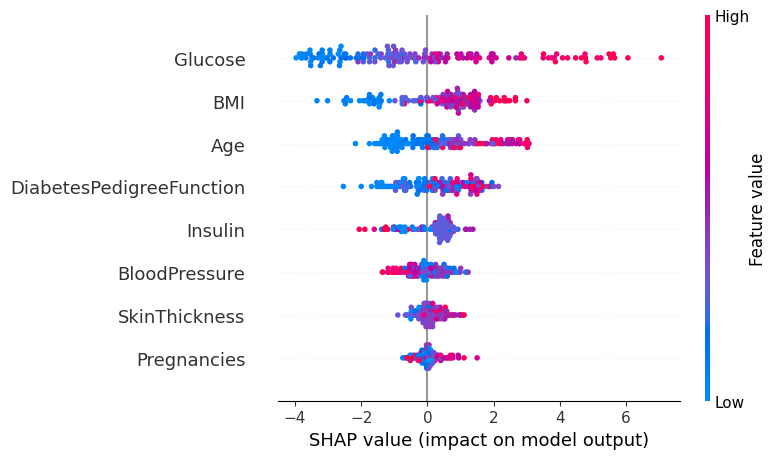


🔍 SHAP Local Explanation (Sample 0)...


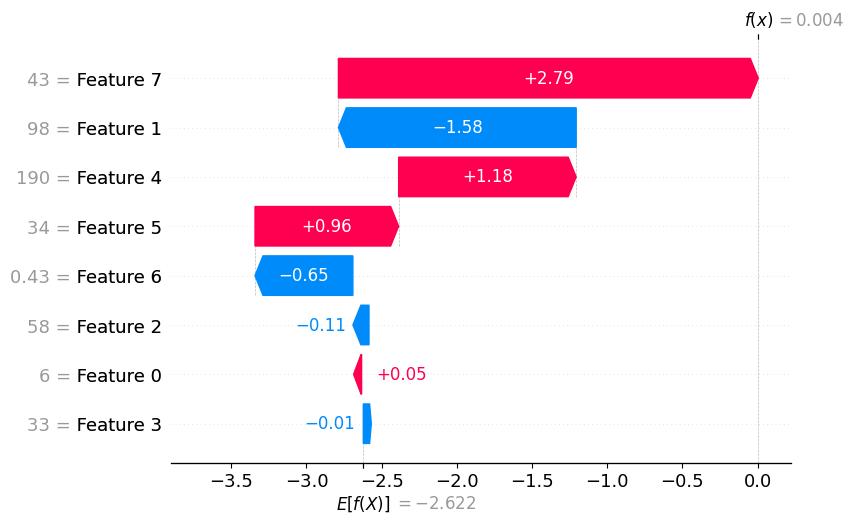


🔍 LIME Explanation...



Enter Patient Data:
Pregnancies: 1
Glucose: 147
BloodPressure: 130
SkinThickness: 34
Insulin: 5
BMI: 26
DiabetesPedigreeFunction: .65
Age: 34


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(



🔥 Prediction: No Diabetes

🔍 SHAP Explanation:


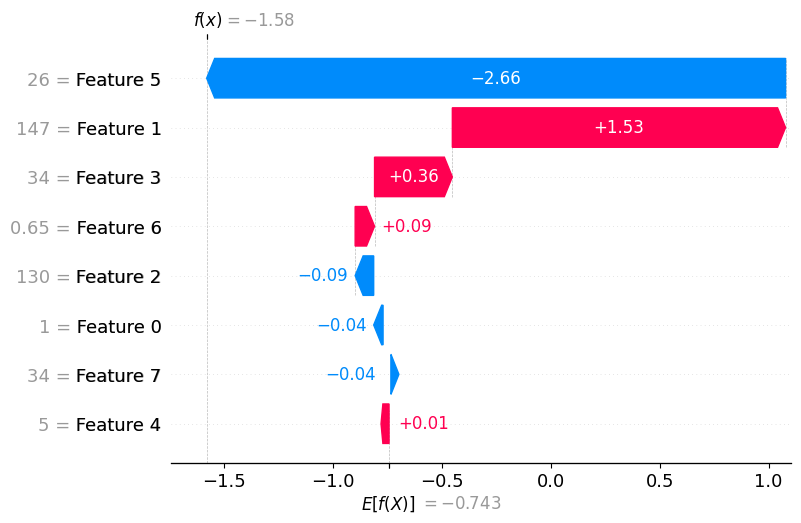


🔍 LIME Explanation:


In [6]:
# ============================================
# 🔥 Diabetes Prediction with Explainable AI
# (SHAP + LIME + Ensemble Models)
# ============================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

# Explainable AI
import shap
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

# 2️⃣ Load Dataset
data = pd.read_excel('/content/drive/MyDrive/Machine_Learning/Project-1/diabetes.csv')

# 3️⃣ Handle Missing Values
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    data[col] = data[col].replace(0, np.nan)

# Impute
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(data.drop('Outcome', axis=1))
y = data['Outcome']

feature_names = data.drop('Outcome', axis=1).columns.tolist()

# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 🔥 Train Models
# ============================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# ============================================
# 📊 Evaluation
# ============================================

models = {
    "Logistic Regression": (log_model, X_test_scaled),
    "Decision Tree": (tree_model, X_test),
    "Random Forest": (rf_model, X_test),
    "Gradient Boosting": (gb_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

print("\n📊 Model Performance:\n")

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*50)

# ============================================
# 🔥 Ensemble
# ============================================

ensemble = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('dt', tree_model),
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_model)
    ],
    voting='hard'
)

ensemble.fit(X_train, y_train)

print("\n🔥 Ensemble Accuracy:",
      accuracy_score(y_test, ensemble.predict(X_test)))

# ============================================
# 💾 Save Models
# ============================================

joblib.dump(imputer, 'imputer.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(ensemble, 'ensemble_model.pkl')

# ============================================
# 🔥 SHAP EXPLANATION
# ============================================

print("\n🔍 SHAP Global Explanation...")

explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Global Feature Importance
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# Local Explanation (first sample)
print("\n🔍 SHAP Local Explanation (Sample 0)...")
shap.plots.waterfall(shap_values[0])

# ============================================
# 🔥 LIME EXPLANATION
# ============================================

print("\n🔍 LIME Explanation...")

lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=["No Diabetes", "Diabetes"],
    mode='classification'
)

# Explain one sample
i = 0
lime_exp = lime_explainer.explain_instance(
    X_test[i],
    xgb_model.predict_proba
)

lime_exp.show_in_notebook(show_table=True)
# OR for script:
# lime_exp.save_to_file("lime_explanation.html")

# ============================================
# 🔮 Prediction + Explanation
# ============================================

def predict_with_explain():
    imputer = joblib.load('imputer.pkl')
    ensemble = joblib.load('ensemble_model.pkl')
    xgb_model = joblib.load('xgb_model.pkl')

    # SHAP
    explainer = shap.Explainer(xgb_model)

    # LIME
    lime_explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=["No Diabetes", "Diabetes"],
        mode='classification'
    )

    print("\nEnter Patient Data:")

    inputs = [
        float(input("Pregnancies: ")),
        float(input("Glucose: ")),
        float(input("BloodPressure: ")),
        float(input("SkinThickness: ")),
        float(input("Insulin: ")),
        float(input("BMI: ")),
        float(input("DiabetesPedigreeFunction: ")),
        float(input("Age: "))
    ]

    data = np.array([inputs])
    data = imputer.transform(data)

    # Prediction
    pred = ensemble.predict(data)[0]

    print("\n🔥 Prediction:", "Diabetes" if pred == 1 else "No Diabetes")

    # 🔥 SHAP Explanation
    shap_values = explainer(data)
    print("\n🔍 SHAP Explanation:")
    shap.plots.waterfall(shap_values[0])

    # 🔥 LIME Explanation
    print("\n🔍 LIME Explanation:")
    lime_exp = lime_explainer.explain_instance(
        data[0],
        xgb_model.predict_proba
    )
    lime_exp.show_in_notebook(show_table=True)

# Run
if __name__ == "__main__":
    predict_with_explain()